## Training a Loan Approval Model
### Objective
The objective of this notebook is to train a binary classification model that can predict fulfilment of loans and hence, automate loan approvals.

### 1. Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

sns.set_theme(style="ticks", palette="pastel")

def remove_outliers(df, col: str):
    q3 = np.quantile(df[col], 0.75)
    q1 = np.quantile(df[col], 0.25)
    l_lmt = q1 - 1.5 * (q3 - q1)
    u_lmt = q3 + 1.5 * (q3 - q1)
    return df[(df[col] >= l_lmt) & (df[col] <= u_lmt)].copy()
    
#Read Sample Dataset
raw_df = pd.read_csv('../data/loan_approval_dataset.csv')
raw_df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,approved
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [2]:
#Check number of records and columns
print(raw_df.shape)

(4269, 13)


In [3]:
#Check of missing values
raw_df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
approved                    0
dtype: int64

In [4]:
raw_df.describe(include='all')

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,approved
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000


In [5]:
def log_txf(df, cols: list):
    for col in cols:
        df[col] = df[col].clip(lower=0)
        df['log_'+col] = np.log(df[col]+1)
    return df

raw_df = log_txf(raw_df, ['income_annum','residential_assets_value','bank_asset_value','loan_amount'])
raw_df.describe(include='all')

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,approved,log_income_annum,log_residential_assets_value,log_bank_asset_value,log_loan_amount
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4269.000000,4269.000000,4269.000000
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.473272e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160,15.182688,15.065062,15.079089,16.255468
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.502878e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904,0.848165,2.320917,1.145963,0.882435
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,0.000000e+00,0.000000e+00,3.000000e+05,0.000000e+00,0.000000,12.206078,0.000000,0.000000,12.611541
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000,14.808763,14.603968,14.648420,15.856731
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000,15.444751,15.538277,15.341567,16.489659
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000,15.830414,16.240313,15.775605,16.883564


[None, None]

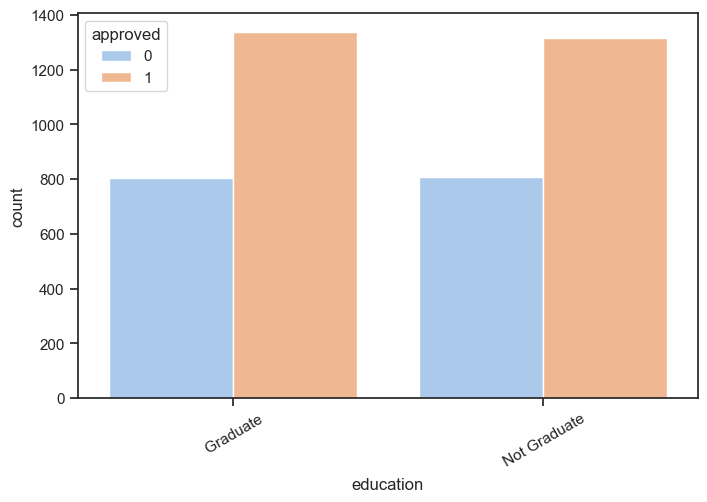

In [6]:
plt.figure(figsize=(8,5))
g = sns.countplot(raw_df, x="education", hue="approved")
plt.setp(g.get_xticklabels(), rotation=30)

[None, None]

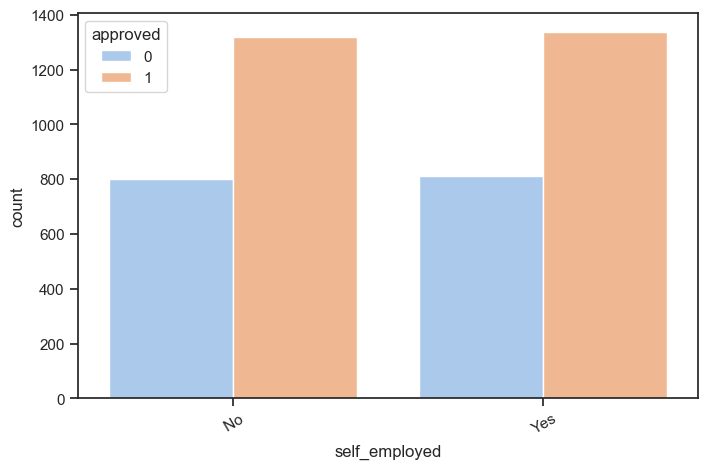

In [7]:
plt.figure(figsize=(8,5))
g = sns.countplot(raw_df, x="self_employed", hue="approved")
plt.setp(g.get_xticklabels(), rotation=30)

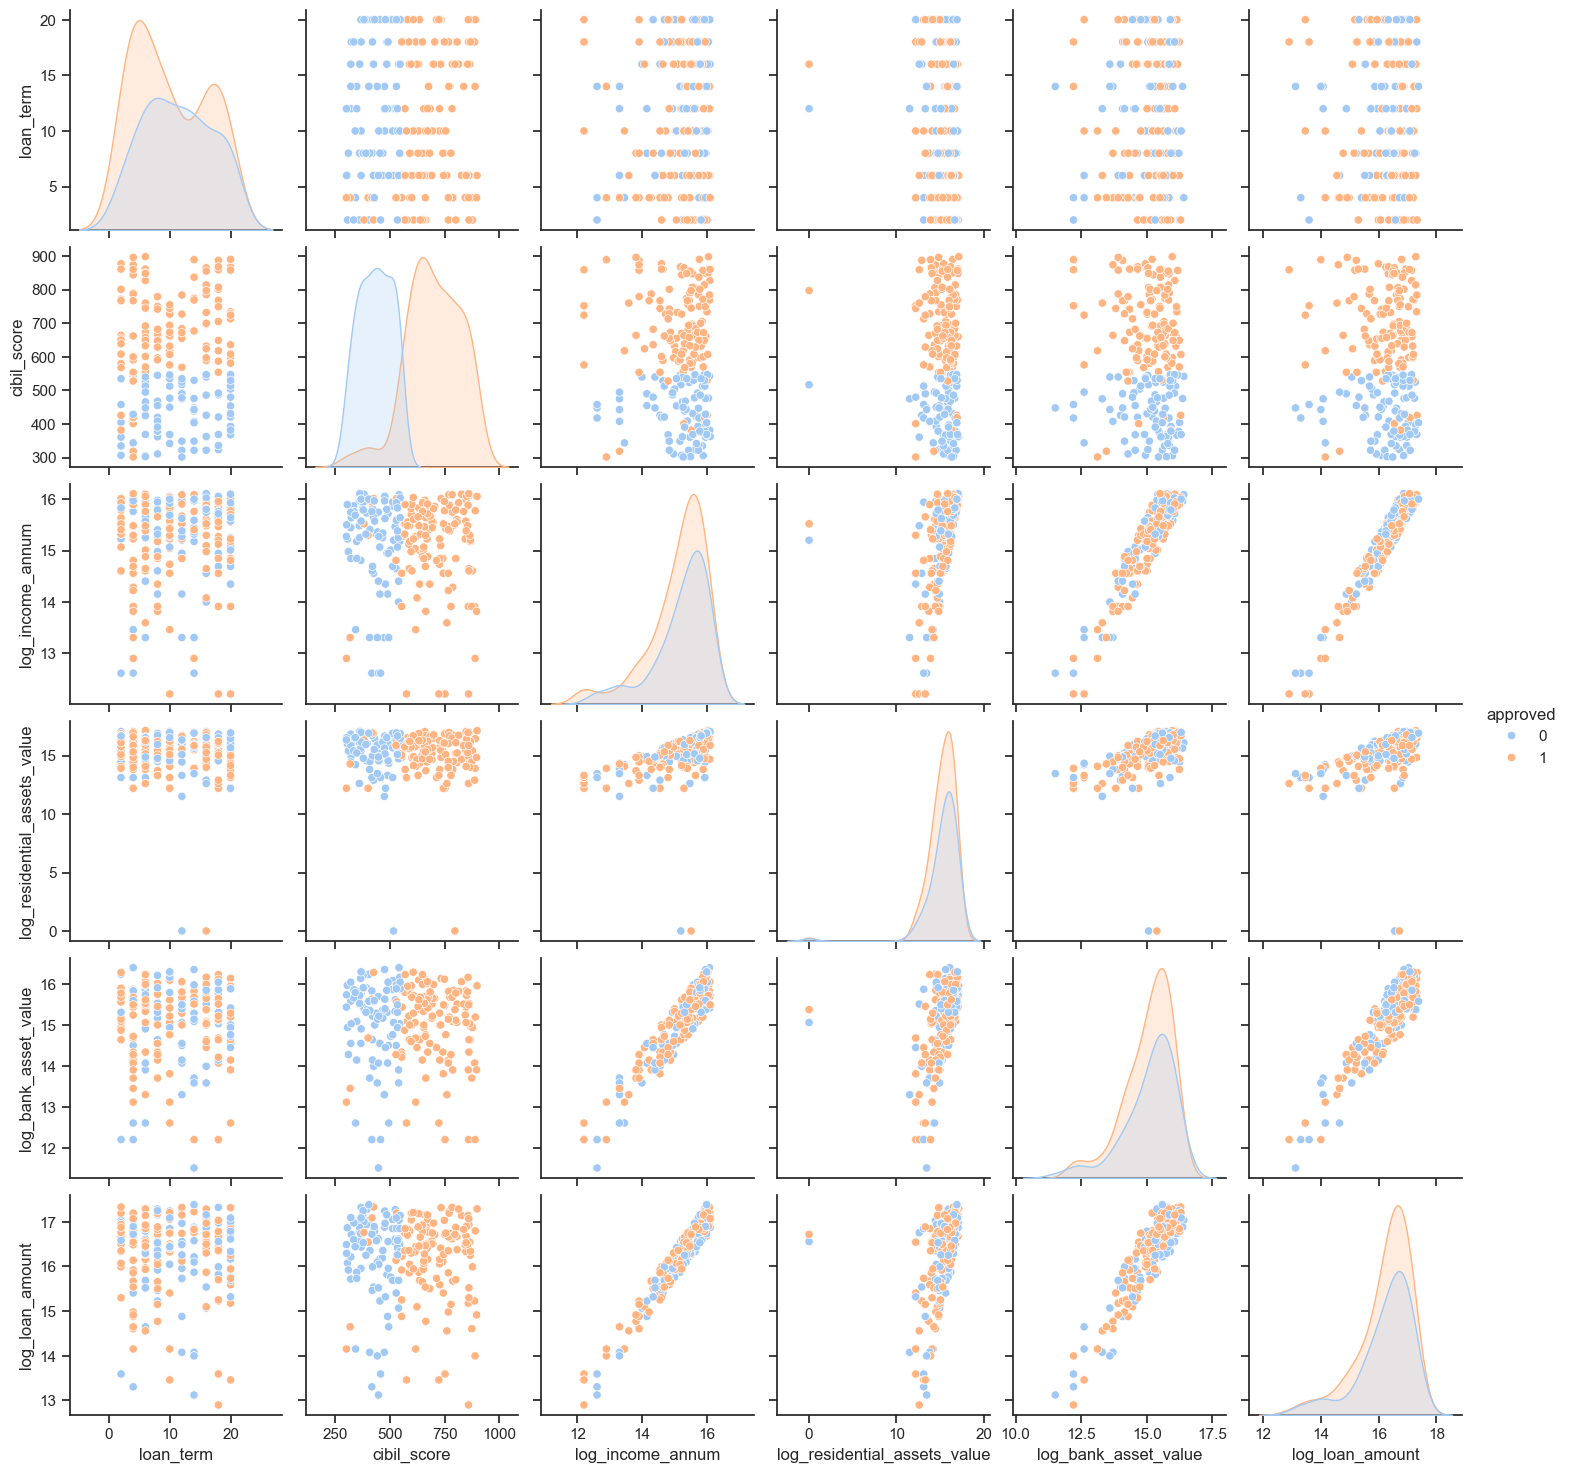

In [8]:
plt_df = raw_df.sample(frac=0.05)
g = sns.pairplot(plt_df[['loan_term','cibil_score','log_income_annum','log_residential_assets_value','log_bank_asset_value','log_loan_amount','approved']], 
                 hue='approved')

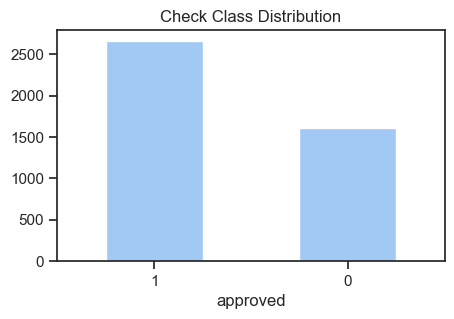

In [9]:
plt.figure(figsize=(5,3))
g = raw_df['approved'].value_counts().plot.bar(title='Check Class Distribution', rot=0)

### 2. Feature Engineering

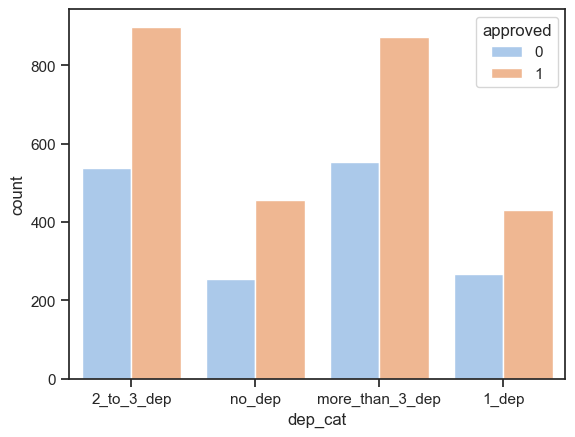

In [10]:
def remap_dependents(x):
    if x == 0:
        return 'no_dep'
    if x == 1:
        return '1_dep'
    if x > 1 and x <= 3:
        return '2_to_3_dep'
    return 'more_than_3_dep'

raw_df['dep_cat'] = raw_df['no_of_dependents'].map(remap_dependents)
g = sns.countplot(raw_df, x="dep_cat", hue="approved")

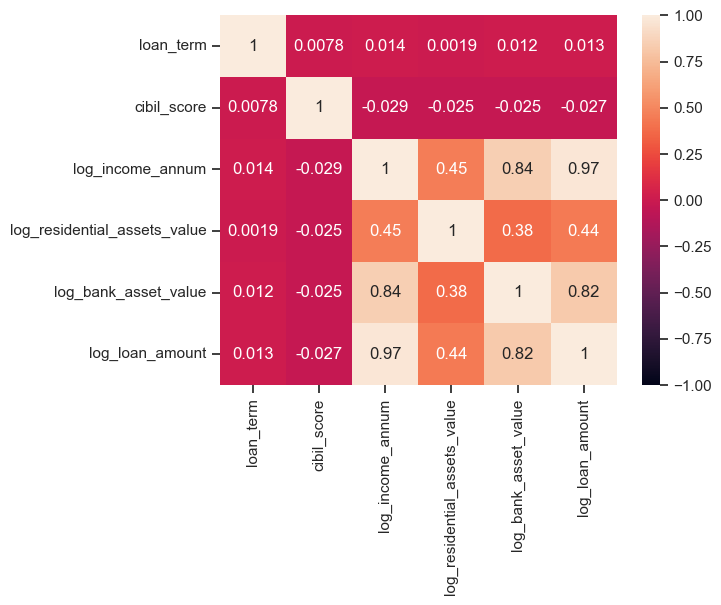

In [11]:
numeric_cols = ['loan_term','cibil_score','log_income_annum','log_residential_assets_value','log_bank_asset_value','log_loan_amount']
g = sns.heatmap(raw_df[numeric_cols].corr(), vmin=-1, vmax=1, annot=True)

### 3. Data Preprocessing

In [12]:
#Select features that are discriminatory and uncorrelated
features = ['dep_cat','loan_term','cibil_score','log_residential_assets_value','log_loan_amount']
numeric_features = ['loan_term','cibil_score','log_residential_assets_value','log_loan_amount']
categorical_features = ['dep_cat']
label = 'approved'

numeric_transformer = MinMaxScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

dat = preprocessor.fit_transform(raw_df)
new_cols = numeric_features + \
list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

trf_df = pd.DataFrame(dat, columns=new_cols)
trf_df.head()

,loan_term,cibil_score,log_residential_assets_value,log_loan_amount,dep_cat_1_dep,dep_cat_2_to_3_dep,dep_cat_more_than_3_dep,dep_cat_no_dep
0,0.555556,0.796667,0.854810,0.942945,0.0,1.0,0.0,0.0
1,0.333333,0.195000,0.861663,0.759262,0.0,0.0,0.0,1.0
2,1.000000,0.343333,0.917920,0.941570,0.0,1.0,0.0,0.0
3,0.333333,0.278333,0.972692,0.948356,0.0,1.0,0.0,0.0
4,1.000000,0.136667,0.950365,0.899606,0.0,0.0,1.0,0.0


### 4. Modeling
#### 4.1 Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(raw_df[features], \
                                                    raw_df[label], \
                                                    test_size=0.2, \
                                                    random_state=0)
X_train.head()

,dep_cat,loan_term,cibil_score,log_residential_assets_value,log_loan_amount
2488,2_to_3_dep,18,547,15.424949,15.671809
3703,1_dep,8,378,16.738672,17.246267
3347,2_to_3_dep,6,601,12.611541,17.445171
3487,more_than_3_dep,12,690,16.694709,16.705882
3957,no_dep,4,374,15.775605,16.213406


#### 4.2 Train Classifier

In [14]:
random_forest = RandomForestClassifier(n_estimators=100,
                                       max_depth=10, 
                                       class_weight = "balanced_subsample",
                                       n_jobs=2)

clf = Pipeline(steps=[("preprocessor", preprocessor),\
                      ("binary_classifier", random_forest)]
              )

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['loan_term', 'cibil_score',
                                                   'log_residential_assets_value',
                                                   'log_loan_amount']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['dep_cat'])])),
                ('binary_classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=10, n_jobs=2))])

### 5. Evaluation

In [15]:
print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       331
           1       0.98      0.97      0.98       523

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



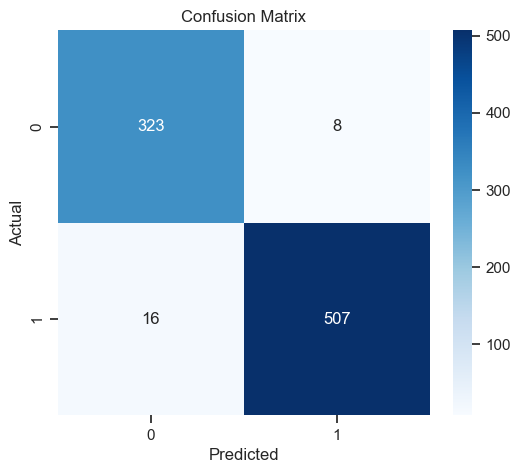

True Positives: 507, True Negatives: 323, False Positives: 8, False Negatives: 16
Recall: 0.97
False Discovery Rate: 0.02


In [16]:
c_matrix = confusion_matrix(y_test, clf.predict(X_test))
TP = c_matrix[1, 1]
TN = c_matrix[0, 0]
FP = c_matrix[0, 1]
FN = c_matrix[1, 0]
plt.figure(figsize=(6, 5))
sns.heatmap(c_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print(f"True Positives: {TP}, True Negatives: {TN}, False Positives: {FP}, False Negatives: {FN}")
print(f"Recall: {TP / (TP + FN):.2f}")
print(f"False Discovery Rate: {FP / (TP + FP):.2f}")